# Initialize the instrument

In [41]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time
from scipy.signal import find_peaks

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR', timeout = 1000)

In [7]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [8]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


# define the pulse

In [9]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

# stepper motor slope
freq_factor = 129 #kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [10]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num = cycle_number, 
                  dwell = 0, sourceA = "INPUT1", sourceB = "INPUT2", gate_A_mode = "FIXED",
                  gate_A_delay = gate_delay, gate_A_width = gate_width, gate_B_mode = "CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [11]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [12]:
bnc575.start_pulses()

# search the resonance

In [14]:
weeder.position(header = "A", query = True)

'A3960'

In [15]:
weeder.move("A", position = 3800, progress = True)

start at 3960 --> 3800.0 --> 3800
Old position: 3960
New position: 3801


In [16]:
weeder.advance(header = "A", num_step = 10)

start at 3801 --> 3811.0 --> 3811
Old position: 3801
New position: 3811


# Stark map

## 1D

In [18]:
center = 3800
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [22]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"now checking step: {idx}", end = "\r", flush=True)
    sr400.count_reset()
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A","+")
    time.sleep(0.1)
e = time.time()
print(e-s)

start at 4000 --> 3500.0 --> 3500
Old position: 4000
New position: 3500
start at 3500 --> 3600.0 --> 3600
Old position: 3500
New position: 3600
88.38020062446594: 399.0


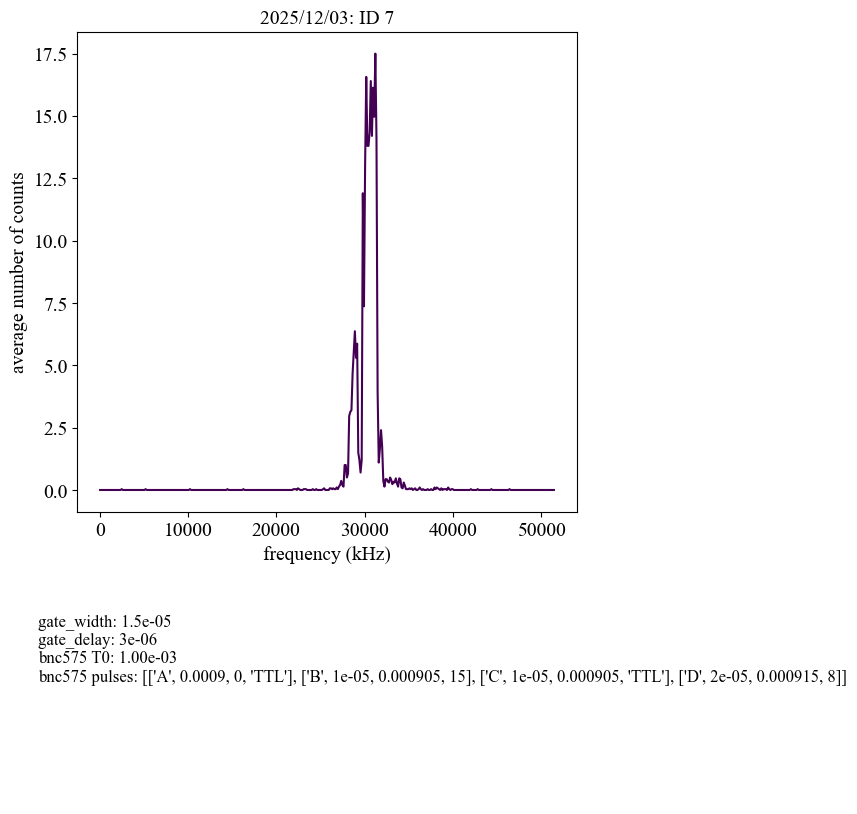

In [23]:
ps.Plot2D(x = x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "frequency (kHz)", zlabel = "average number of counts", notes = notes)

## 2D

### frequency inside

In [ ]:
center = 3700
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [ ]:
start_position = center - half_width

v_list = np.linspace(-1,1,11)
stark_map = []

s = time.time()
for v in v_list:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.1)
    stark_map.append(results)

e = time.time()
print(e-s)

In [ ]:
ps.Plot3D(x = v_list, y =x_list*stride*freq_factor , Z = stark_map,
          xlabel = "x voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

### voltage inside

In [93]:
center = 3800
stride = 1
half_width = 200


# scan list gneration
s_list = np.arange(2* half_width/stride)

# the 0 point

vset = np.array([0.2,-0.1,0.48])

vx_list = np.linspace(-0.8,0.8,11) + vset[0]
vy_list = np.linspace(-0.8,0.8,11) + vset[1]
vz_list = np.linspace(-0.8,1.6,11) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

v_list = v_list + vset.reshape(-1,1)

electrode_pair = [[10,11],[6,7],[0,1]]

In [94]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vset[0], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vset[0], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vset[1], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vset[1], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vset[2], bipolar = True, display=True)

Channel 10 has been set to 0.2 V.
Channel 11 has been set to -0.2 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 0 has been set to 0 V.
Channel 1 has been set to -0.48 V.


In [106]:
start_position = center - half_width

stark_map = []

i = 1

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)
for s in s_list:
    for j in range(stride):
            weeder.step("A","+")
    print(f"now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
        else:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display=False)
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display=False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A",length = cycle_number))
        results.append(result)
        
    stark_map.append(results)

Now checking axis 1
start at 4000 --> 3500.0 --> 3500
Old position: 4000
New position: 3500
start at 3500 --> 3600.0 --> 3600
Old position: 3500
New position: 3600


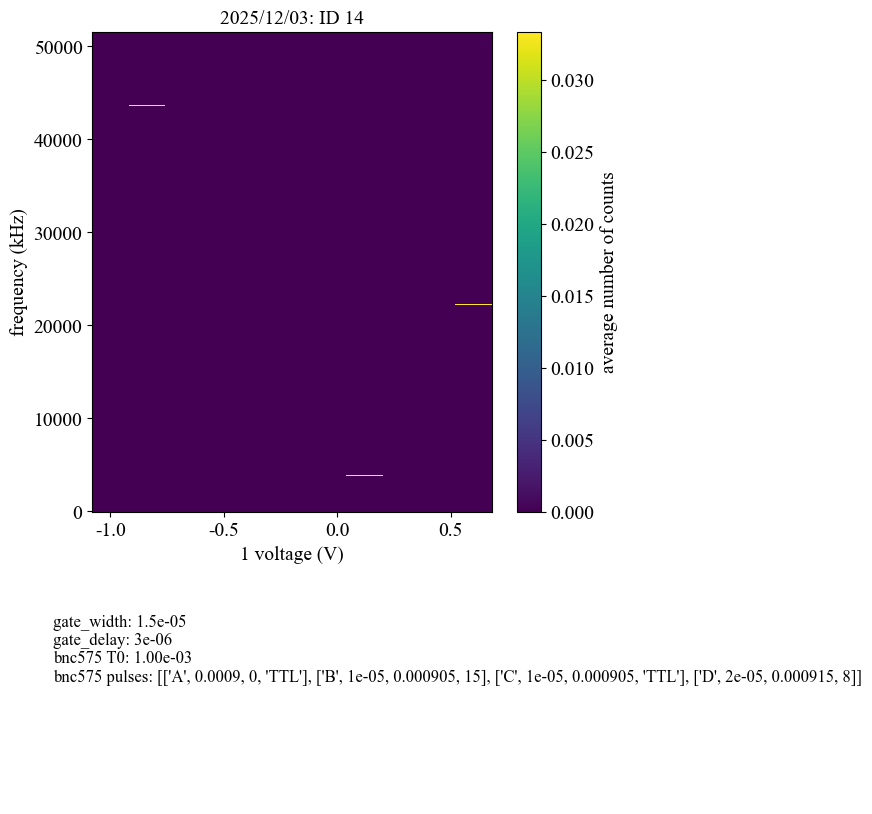

In [107]:
ps.Plot3D(x = v_list[i], y =s_list*stride*freq_factor , Z = np.array(stark_map).T,
          xlabel = f"{i} voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

In [104]:
peaks_x = []
peaks_y = []
peaks_list = []
for k in range(len(stark_map[0])):
    freq_scan = np.array(stark_map)[:,k]
    peaks,_ = find_peaks(freq_scan,height = 4, distance= 8)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(v_list[i][k])
            peaks_y.append((s_list*stride*freq_factor)[p])
        peaks_list.append(peaks)
peaks_list = np.array(peaks_list)
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T

[223 232 240 253]
[227 237 245 255]
[240 248]
[247]
[246]
[244]
[238 248]
[232 245 255]
[225 239 251]
[209 243 253]
[198 233 241 257]


In [69]:
i

1

In [58]:
print(v_list)

[[-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
 [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
 [-1.  -0.7 -0.4 -0.1  0.2  0.5  0.8  1.1  1.4  1.7  2. ]]


0.8260740740740734


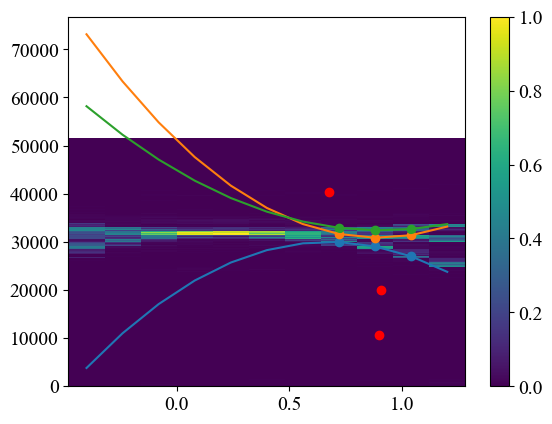

In [105]:
plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
ssum = 0 
for l in range(3):
    a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
    plt.scatter(peaks_x[l],peaks_y[l])
    plt.plot(v_list[i], a * v_list[i]**2 + b * v_list[i] +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    ssum += -b/(2*a)
print(ssum/3)
plt.colorbar()

# End

In [33]:
mcbox.set_voltage_Nchan(board_num=0,channels= [0,1,6,7,10,11], voltages = [0,0,0,0,0,0], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to 0 V.
Channel 6 has been set to 0 V.
Channel 7 has been set to 0 V.
Channel 10 has been set to 0 V.
Channel 11 has been set to 0 V.
Voltages successfully set.
